# Why Residual Connections Work: A Deep Dive

Residual connections (skip connections) are one of the most important architectural innovations in deep learning. This notebook provides an **intuitive and visual exploration** of why they work so effectively.

## What We'll Explore

1. **The Problem**: Why vanilla deep networks fail to train
2. **The Residual Reformulation**: Learning differences instead of functions
3. **Gradient Flow Analysis**: The mathematical magic of skip connections
4. **Loss Landscape Geometry**: How residuals smooth the optimization surface
5. **The Ensemble Interpretation**: ResNets as exponentially many paths
6. **Feature Reuse**: Why skipping enables richer representations

## Prerequisites

- Basic understanding of neural networks and backpropagation
- Familiarity with PyTorch

## Key Insight Preview

Residual connections work not because they're complicated, but because they're **simple**:

```
output = F(x) + x
```

This one-line addition fundamentally changes the optimization dynamics, making deep networks trainable.


## Setup


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import proj3d
import warnings
warnings.filterwarnings('ignore')

# Import shared utilities
from aiml_notebooks import get_device, set_seed

set_seed(42)
device = get_device()
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")


Using CUDA GPU: NVIDIA GeForce RTX 4090
Using device: cuda
PyTorch version: 2.9.0+cu128


---
## Part 1: The Problem - Why Deep Networks Fail

### The Paradox of Depth

Before 2015, a puzzling paradox existed: **deeper networks performed worse than shallower ones**, even on training data.

This wasn't overfitting—the training error itself was higher. If a 20-layer network can fit the data, surely a 56-layer network should do at least as well (it could just learn identity for the extra layers). But it couldn't.

Let's visualize this degradation problem.


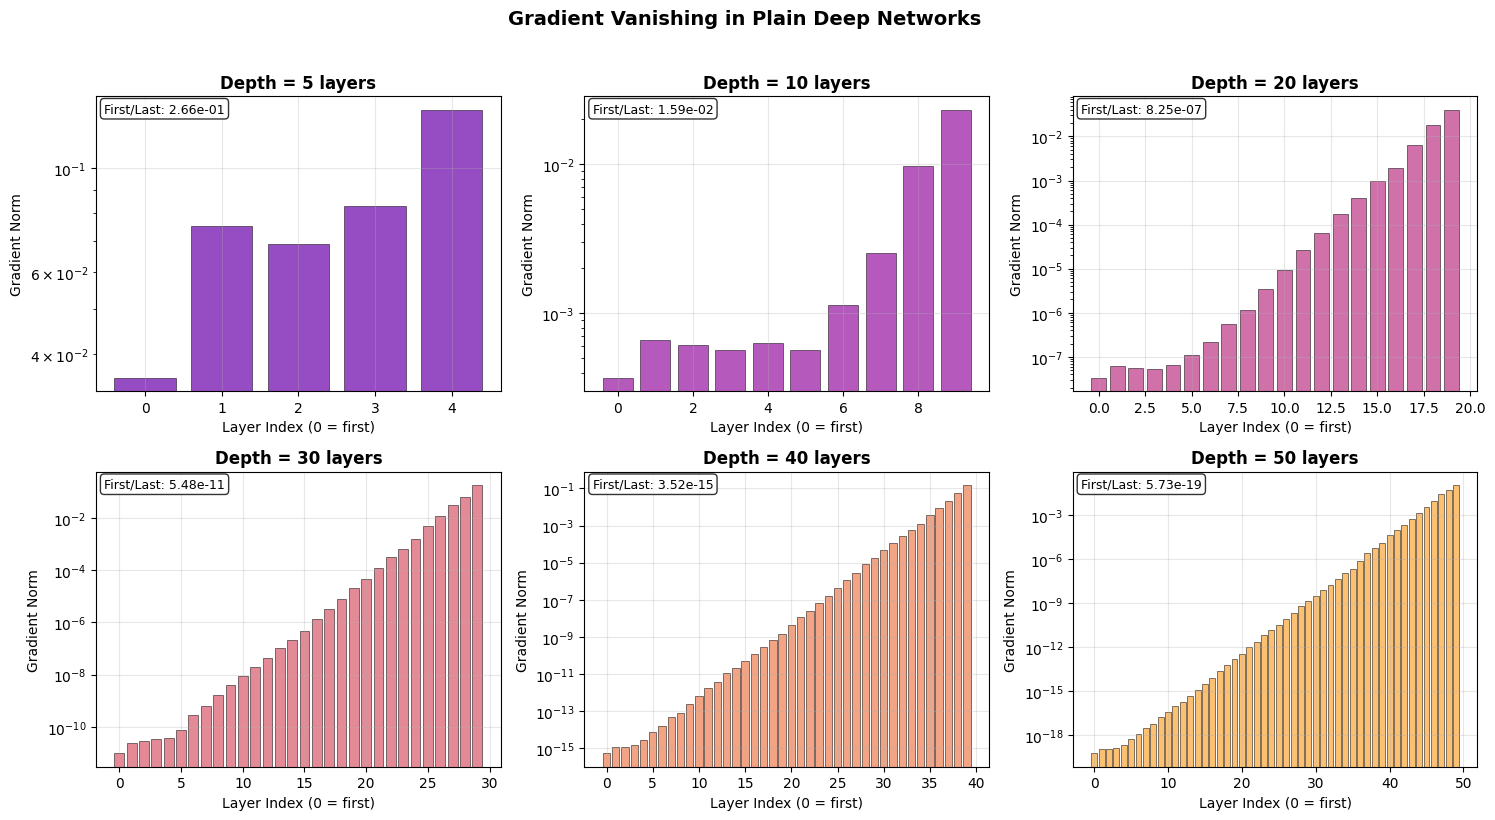


📉 Key Observation:
   Gradients at early layers become exponentially smaller as depth increases.
   This means early layers barely learn—they're effectively frozen!


In [2]:
def create_plain_network(depth, hidden_size=128):
    """Create a plain (vanilla) deep network without skip connections."""
    layers = [nn.Linear(32, hidden_size), nn.ReLU()]
    for _ in range(depth - 2):
        layers.extend([nn.Linear(hidden_size, hidden_size), nn.ReLU()])
    layers.append(nn.Linear(hidden_size, 1))
    return nn.Sequential(*layers)

def measure_gradient_stats(model, loss_fn):
    """Measure gradient statistics through the network."""
    model.zero_grad()
    x = torch.randn(64, 32, device=device)
    y = torch.randn(64, 1, device=device)
    
    output = model(x)
    loss = loss_fn(output, y)
    loss.backward()
    
    grad_norms = []
    for name, param in model.named_parameters():
        if 'weight' in name and param.grad is not None:
            grad_norms.append(param.grad.norm().item())
    
    return grad_norms

# Test different depths
depths = [5, 10, 20, 30, 40, 50]
all_grad_norms = {}

for depth in depths:
    model = create_plain_network(depth).to(device)
    grad_norms = measure_gradient_stats(model, nn.MSELoss())
    all_grad_norms[depth] = grad_norms

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(depths)))

for idx, depth in enumerate(depths):
    ax = axes[idx]
    grads = all_grad_norms[depth]
    layer_indices = np.arange(len(grads))
    
    ax.bar(layer_indices, grads, color=colors[idx], alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.set_title(f'Depth = {depth} layers', fontsize=12, fontweight='bold')
    ax.set_xlabel('Layer Index (0 = first)')
    ax.set_ylabel('Gradient Norm')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    
    # Annotate the ratio
    if len(grads) > 1:
        ratio = grads[0] / (grads[-1] + 1e-12)
        ax.text(0.02, 0.98, f'First/Last: {ratio:.2e}', 
                transform=ax.transAxes, fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Gradient Vanishing in Plain Deep Networks', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📉 Key Observation:")
print("   Gradients at early layers become exponentially smaller as depth increases.")
print("   This means early layers barely learn—they're effectively frozen!")


### The Core Issue: Learning Identity is Hard

When we add layers to a network, ideally the extra layers should learn the **identity function** if they're not needed. But learning $H(x) = x$ with a multi-layer network is surprisingly difficult.

Let's see why.


Training plain block to learn identity...
Training residual block to learn identity...


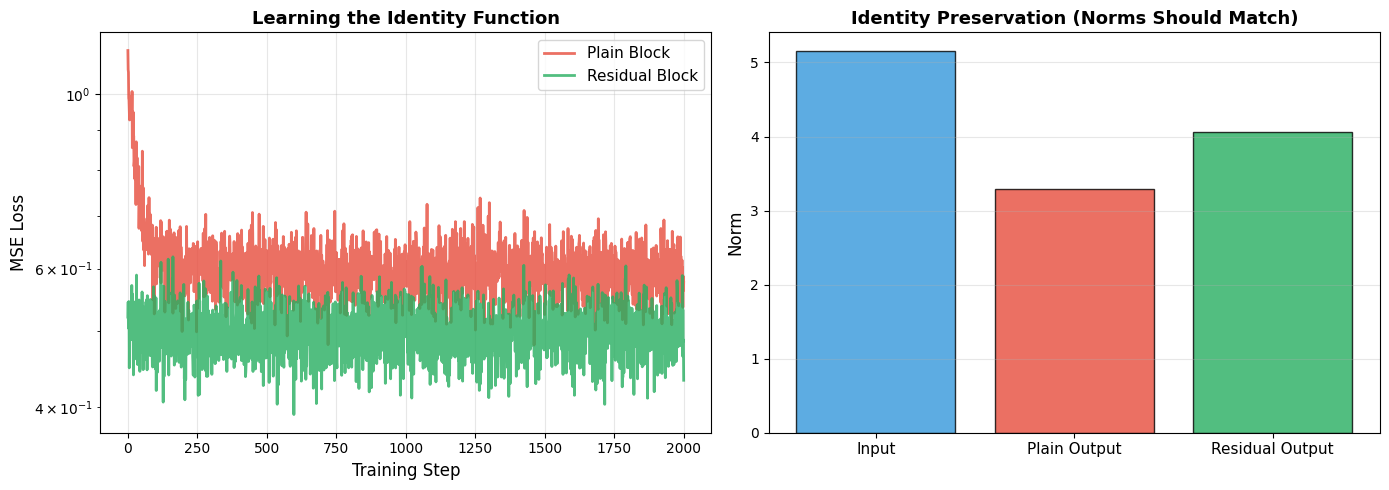


📊 Final MSE Loss:
   Plain Block:    0.576103
   Residual Block: 0.432802
   Improvement:    1.3x better!


In [3]:
class PlainBlock(nn.Module):
    """A plain block that must learn to pass through input."""
    def __init__(self, size):
        super().__init__()
        self.fc1 = nn.Linear(size, size)
        self.fc2 = nn.Linear(size, size)
    
    def forward(self, x):
        return F.relu(self.fc2(F.relu(self.fc1(x))))

class ResidualBlock(nn.Module):
    """A residual block with skip connection."""
    def __init__(self, size):
        super().__init__()
        self.fc1 = nn.Linear(size, size)
        self.fc2 = nn.Linear(size, size)
    
    def forward(self, x):
        return F.relu(self.fc2(F.relu(self.fc1(x))) + x)  # The magic: + x

def train_identity(model, steps=2000, lr=0.01):
    """Train a model to learn the identity function."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    
    for _ in range(steps):
        x = torch.randn(64, 16, device=device)
        y = model(x)
        loss = F.mse_loss(y, x)  # Target: output should equal input
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    
    return losses

# Train both blocks to learn identity
plain_block = PlainBlock(16).to(device)
residual_block = ResidualBlock(16).to(device)

print("Training plain block to learn identity...")
plain_losses = train_identity(plain_block)
print("Training residual block to learn identity...")
residual_losses = train_identity(residual_block)

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(plain_losses, label='Plain Block', color='#e74c3c', linewidth=2, alpha=0.8)
ax1.plot(residual_losses, label='Residual Block', color='#27ae60', linewidth=2, alpha=0.8)
ax1.set_xlabel('Training Step', fontsize=12)
ax1.set_ylabel('MSE Loss', fontsize=12)
ax1.set_title('Learning the Identity Function', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# Show final reconstruction quality
x_test = torch.randn(1, 16, device=device)
with torch.no_grad():
    plain_out = plain_block(x_test)
    res_out = residual_block(x_test)

ax2.bar([0, 1, 2], [
    x_test.norm().item(),
    plain_out.norm().item(),
    res_out.norm().item()
], color=['#3498db', '#e74c3c', '#27ae60'], alpha=0.8, edgecolor='black')
ax2.set_xticks([0, 1, 2])
ax2.set_xticklabels(['Input', 'Plain Output', 'Residual Output'], fontsize=11)
ax2.set_ylabel('Norm', fontsize=12)
ax2.set_title('Identity Preservation (Norms Should Match)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n📊 Final MSE Loss:")
print(f"   Plain Block:    {plain_losses[-1]:.6f}")
print(f"   Residual Block: {residual_losses[-1]:.6f}")
print(f"   Improvement:    {plain_losses[-1]/residual_losses[-1]:.1f}x better!")


### Why This Happens

**Plain Block**: Must learn weights such that W2(ReLU(W1 x)) = x
- This requires the network to learn the inverse relationship
- ReLU makes exact inversion impossible (information is lost at negative values)
- The optimization landscape is complex

**Residual Block**: Must learn weights such that W2(ReLU(W1 x)) = 0
- Just needs to push weights toward zero!
- Much easier optimization target
- The skip connection handles identity automatically


---
## Part 2: The Residual Reformulation

### The Elegant Insight

Instead of asking the network to learn:
$$H(x) = \text{desired output}$$

We ask it to learn:
$$F(x) = H(x) - x = \text{what to add to input}$$

Then: $H(x) = F(x) + x$

This is the **residual** (the difference from identity).


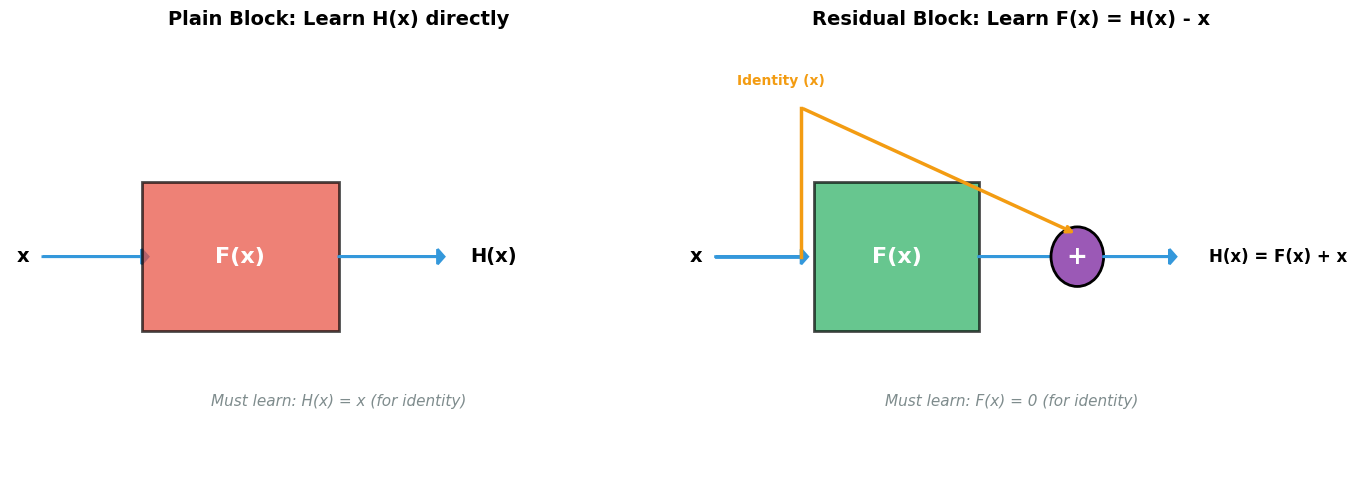


💡 Key Insight:
   The skip connection provides the identity 'for free'.
   The network only needs to learn what to ADD to the input.
   Learning F(x) = 0 (just push weights to zero) is much easier than learning H(x) = x.


In [4]:
# Visual diagram of residual connection
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plain block diagram
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 6)
ax1.axis('off')
ax1.set_title('Plain Block: Learn H(x) directly', fontsize=14, fontweight='bold')

# Draw plain block
ax1.arrow(0.5, 3, 1.5, 0, head_width=0.2, head_length=0.1, fc='#3498db', ec='#3498db', linewidth=2)
ax1.add_patch(plt.Rectangle((2, 2), 3, 2, facecolor='#e74c3c', edgecolor='black', linewidth=2, alpha=0.7))
ax1.text(3.5, 3, 'F(x)', fontsize=16, ha='center', va='center', fontweight='bold', color='white')
ax1.arrow(5, 3, 1.5, 0, head_width=0.2, head_length=0.1, fc='#3498db', ec='#3498db', linewidth=2)
ax1.text(0.3, 3, 'x', fontsize=14, ha='right', va='center', fontweight='bold')
ax1.text(7, 3, 'H(x)', fontsize=14, ha='left', va='center', fontweight='bold')
ax1.text(5, 1, 'Must learn: H(x) = x (for identity)', fontsize=11, ha='center', style='italic', color='#7f8c8d')

# Residual block diagram
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 6)
ax2.axis('off')
ax2.set_title('Residual Block: Learn F(x) = H(x) - x', fontsize=14, fontweight='bold')

# Draw residual block
ax2.arrow(0.5, 3, 1.3, 0, head_width=0.2, head_length=0.1, fc='#3498db', ec='#3498db', linewidth=2)
ax2.add_patch(plt.Rectangle((2, 2), 2.5, 2, facecolor='#27ae60', edgecolor='black', linewidth=2, alpha=0.7))
ax2.text(3.25, 3, 'F(x)', fontsize=16, ha='center', va='center', fontweight='bold', color='white')
ax2.arrow(4.5, 3, 1.3, 0, head_width=0.2, head_length=0.1, fc='#3498db', ec='#3498db', linewidth=2)

# Skip connection
ax2.annotate('', xy=(6, 3.3), xytext=(1.8, 5),
            arrowprops=dict(arrowstyle='->', color='#f39c12', lw=2.5))
ax2.plot([0.5, 1.8], [3, 3], color='#3498db', linewidth=2)
ax2.plot([1.8, 1.8], [3, 5], color='#f39c12', linewidth=2.5)

# Addition circle
circle = plt.Circle((6, 3), 0.4, facecolor='#9b59b6', edgecolor='black', linewidth=2)
ax2.add_patch(circle)
ax2.text(6, 3, '+', fontsize=18, ha='center', va='center', fontweight='bold', color='white')

ax2.arrow(6.4, 3, 1, 0, head_width=0.2, head_length=0.1, fc='#3498db', ec='#3498db', linewidth=2)
ax2.text(0.3, 3, 'x', fontsize=14, ha='right', va='center', fontweight='bold')
ax2.text(8, 3, 'H(x) = F(x) + x', fontsize=12, ha='left', va='center', fontweight='bold')
ax2.text(1.5, 5.3, 'Identity (x)', fontsize=10, ha='center', color='#f39c12', fontweight='bold')
ax2.text(5, 1, 'Must learn: F(x) = 0 (for identity)', fontsize=11, ha='center', style='italic', color='#7f8c8d')

plt.tight_layout()
plt.show()

print("\n💡 Key Insight:")
print("   The skip connection provides the identity 'for free'.")
print("   The network only needs to learn what to ADD to the input.")
print("   Learning F(x) = 0 (just push weights to zero) is much easier than learning H(x) = x.")


### Visualizing the Residual

Let's see what a trained residual block actually learns - the "residual" or difference from identity.


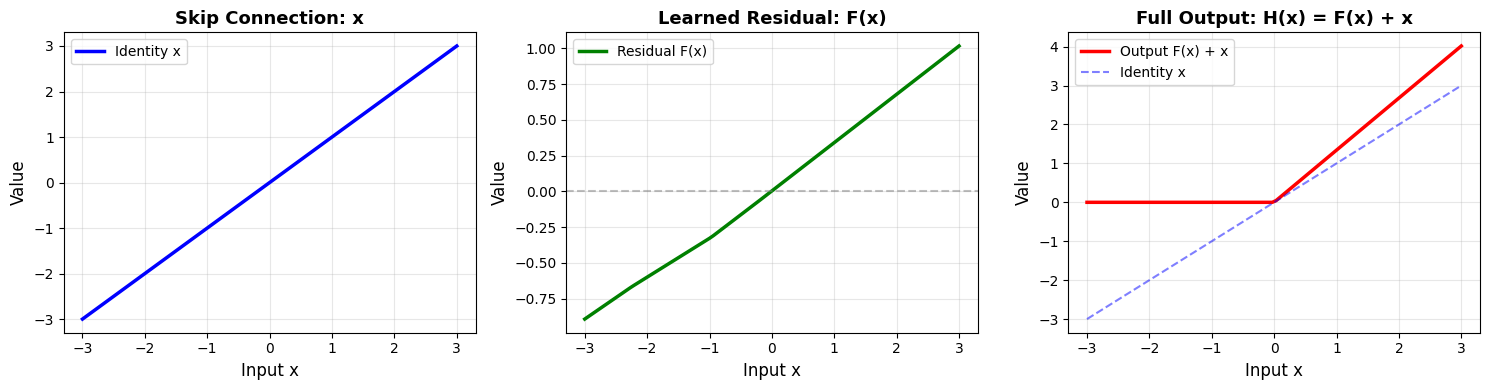


🔍 What the network learned:
   - The skip connection (left) provides the identity baseline
   - The residual F(x) (middle) learns only the DIFFERENCE from identity
   - The final output (right) is the sum of both
   - Notice: F(x) is small compared to x - it's a refinement, not a full transformation!


In [5]:
class AnalyzableResBlock(nn.Module):
    """Residual block that exposes the residual F(x) separately."""
    def __init__(self, size):
        super().__init__()
        self.fc1 = nn.Linear(size, size)
        self.fc2 = nn.Linear(size, size)
    
    def residual(self, x):
        """Just the F(x) part."""
        return self.fc2(F.relu(self.fc1(x)))
    
    def forward(self, x):
        return F.relu(self.residual(x) + x)

# Create a simple task: transform input
def generate_task_data(n_samples, input_dim):
    """Generate data for a simple transformation task."""
    x = torch.randn(n_samples, input_dim, device=device)
    # Target: slight modification of input
    y = x + 0.3 * torch.sin(x) + 0.1 * x ** 2
    return x, y

# Train the residual block
res_block = AnalyzableResBlock(8).to(device)
optimizer = torch.optim.Adam(res_block.parameters(), lr=0.01)

for _ in range(1000):
    x, y = generate_task_data(128, 8)
    output = res_block(x)
    loss = F.mse_loss(output, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Analyze what the block learned
x_test = torch.linspace(-3, 3, 100, device=device).unsqueeze(1).expand(-1, 8)
with torch.no_grad():
    residual_part = res_block.residual(x_test)[:, 0].cpu()
    full_output = res_block(x_test)[:, 0].cpu()
    identity_part = x_test[:, 0].cpu()

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

x_np = x_test[:, 0].cpu().numpy()

axes[0].plot(x_np, identity_part.numpy(), 'b-', linewidth=2.5, label='Identity x')
axes[0].set_xlabel('Input x', fontsize=12)
axes[0].set_ylabel('Value', fontsize=12)
axes[0].set_title('Skip Connection: x', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)

axes[1].plot(x_np, residual_part.numpy(), 'g-', linewidth=2.5, label='Residual F(x)')
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Input x', fontsize=12)
axes[1].set_ylabel('Value', fontsize=12)
axes[1].set_title('Learned Residual: F(x)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)

axes[2].plot(x_np, full_output.numpy(), 'r-', linewidth=2.5, label='Output F(x) + x')
axes[2].plot(x_np, identity_part.numpy(), 'b--', linewidth=1.5, alpha=0.5, label='Identity x')
axes[2].set_xlabel('Input x', fontsize=12)
axes[2].set_ylabel('Value', fontsize=12)
axes[2].set_title('Full Output: H(x) = F(x) + x', fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.show()

print("\n🔍 What the network learned:")
print("   - The skip connection (left) provides the identity baseline")
print("   - The residual F(x) (middle) learns only the DIFFERENCE from identity")
print("   - The final output (right) is the sum of both")
print("   - Notice: F(x) is small compared to x - it's a refinement, not a full transformation!")


---
## Part 3: Gradient Flow - The Mathematical Magic

### The Gradient Highway

The most powerful benefit of residual connections is how they affect **backpropagation**.

For a residual block: $y = F(x) + x$

The gradient during backprop:
$$\frac{\partial y}{\partial x} = \frac{\partial F(x)}{\partial x} + 1$$

That **+1** is the magic. Even if $\frac{\partial F(x)}{\partial x}$ vanishes, the gradient through the skip connection is always **exactly 1**.


Measuring gradient flow at different depths...

Depth  2: Plain=0.0936, Residual=0.3945
Depth  4: Plain=0.0960, Residual=0.3924
Depth  8: Plain=0.0951, Residual=0.3943
Depth 16: Plain=0.0907, Residual=0.4088
Depth 32: Plain=0.0938, Residual=0.3851
Depth 64: Plain=0.0000, Residual=0.3916


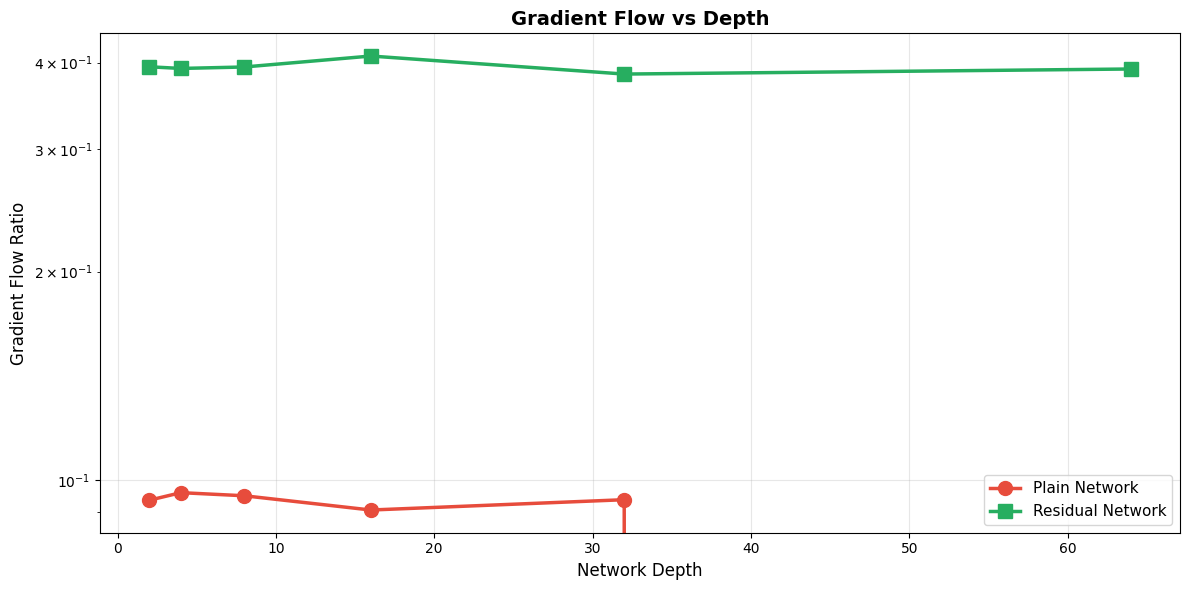


🚀 The +1 in each term prevents exponential decay!
   This is the 'gradient highway' - information flows directly from loss to early layers.


In [6]:
class PlainDeepNet(nn.Module):
    def __init__(self, depth):
        super().__init__()
        layers = []
        for _ in range(depth):
            layers.extend([nn.Linear(32, 32), nn.ReLU()])
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)

class ResidualDeepNet(nn.Module):
    def __init__(self, depth):
        super().__init__()
        self.blocks = nn.ModuleList([ResidualBlock(32) for _ in range(depth)])
    
    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        return x

def compute_gradient_flow(model_fn, depth, n_trials=10):
    """Compute gradient flow statistics for a model."""
    all_ratios = []
    
    for _ in range(n_trials):
        model = model_fn(depth).to(device)
        model.zero_grad()
        
        x = torch.randn(32, 32, device=device, requires_grad=True)
        y = model(x)
        loss = y.sum()
        loss.backward()
        
        # Get gradient at input
        input_grad = x.grad.norm().item()
        
        # Get gradient at last layer weights
        last_layer_grad = None
        for name, param in model.named_parameters():
            if param.grad is not None:
                last_layer_grad = param.grad.norm().item()
                break  # First layer (furthest from output)
        
        if last_layer_grad and last_layer_grad > 0:
            all_ratios.append(input_grad / last_layer_grad)
    
    return np.mean(all_ratios) if all_ratios else 0

# Compare gradient flow
depths = [2, 4, 8, 16, 32, 64]
plain_gradients = []
residual_gradients = []

print("Measuring gradient flow at different depths...\n")
for d in depths:
    plain_g = compute_gradient_flow(PlainDeepNet, d)
    res_g = compute_gradient_flow(ResidualDeepNet, d // 2)  # Same effective depth
    plain_gradients.append(plain_g)
    residual_gradients.append(res_g)
    print(f"Depth {d:2d}: Plain={plain_g:.4f}, Residual={res_g:.4f}")

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(depths, plain_gradients, 'o-', linewidth=2.5, markersize=10, 
         label='Plain Network', color='#e74c3c')
ax.plot(depths, residual_gradients, 's-', linewidth=2.5, markersize=10, 
         label='Residual Network', color='#27ae60')
ax.set_xlabel('Network Depth', fontsize=12)
ax.set_ylabel('Gradient Flow Ratio', fontsize=12)
ax.set_title('Gradient Flow vs Depth', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

print("\n🚀 The +1 in each term prevents exponential decay!")
print("   This is the 'gradient highway' - information flows directly from loss to early layers.")


### Visualizing the Gradient Highway

Let's create an intuitive visualization of how gradients flow through both architectures.


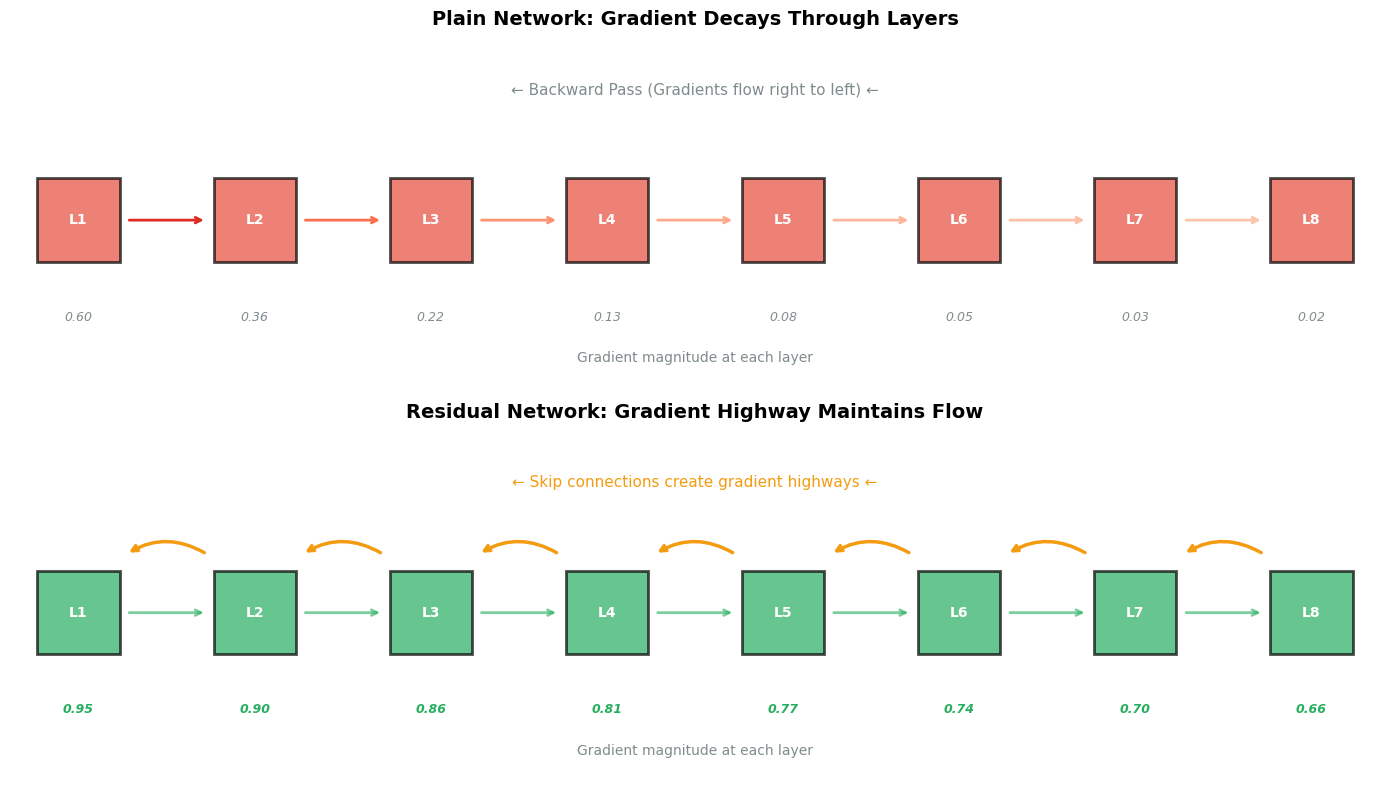

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Settings
n_layers = 8
layer_positions = np.linspace(0.5, 9.5, n_layers)

# Plain network - gradient decays
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 4)
ax1.axis('off')
ax1.set_title('Plain Network: Gradient Decays Through Layers', fontsize=14, fontweight='bold', pad=20)

gradient_strength = 1.0
decay_factor = 0.6

for i, pos in enumerate(layer_positions):
    # Draw layer box
    rect = plt.Rectangle((pos - 0.3, 1.5), 0.6, 1, 
                          facecolor='#e74c3c', edgecolor='black', linewidth=2, alpha=0.7)
    ax1.add_patch(rect)
    ax1.text(pos, 2, f'L{i+1}', ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    
    # Draw gradient arrow (strength decreases)
    gradient_strength *= decay_factor
    arrow_width = 0.15 * (1 - gradient_strength) + 0.02
    color_intensity = 0.2 + 0.8 * gradient_strength
    
    if i < n_layers - 1:
        ax1.annotate('', xy=(layer_positions[i+1] - 0.35, 2), xytext=(pos + 0.35, 2),
                    arrowprops=dict(arrowstyle='->', color=plt.cm.Reds(color_intensity), lw=2))
    
    # Show gradient magnitude
    ax1.text(pos, 0.8, f'{gradient_strength:.2f}', ha='center', fontsize=9, 
             color='#7f8c8d', style='italic')

ax1.text(5, 3.5, '← Backward Pass (Gradients flow right to left) ←', fontsize=11, ha='center', color='#7f8c8d')
ax1.text(5, 0.3, 'Gradient magnitude at each layer', fontsize=10, ha='center', color='#7f8c8d')

# Residual network - gradient maintained
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 4)
ax2.axis('off')
ax2.set_title('Residual Network: Gradient Highway Maintains Flow', fontsize=14, fontweight='bold', pad=20)

gradient_strength = 1.0

for i, pos in enumerate(layer_positions):
    # Draw layer box
    rect = plt.Rectangle((pos - 0.3, 1.5), 0.6, 1, 
                          facecolor='#27ae60', edgecolor='black', linewidth=2, alpha=0.7)
    ax2.add_patch(rect)
    ax2.text(pos, 2, f'L{i+1}', ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    
    # Draw skip connection (highway)
    if i < n_layers - 1:
        # Curved skip connection above
        ax2.annotate('', xy=(pos + 0.35, 2.7), xytext=(layer_positions[i+1] - 0.35, 2.7),
                    arrowprops=dict(arrowstyle='->', color='#f39c12', lw=2.5,
                                   connectionstyle='arc3,rad=0.3'))
        # Regular path below
        ax2.annotate('', xy=(layer_positions[i+1] - 0.35, 2), xytext=(pos + 0.35, 2),
                    arrowprops=dict(arrowstyle='->', color='#27ae60', lw=2, alpha=0.6))
    
    # Gradient stays strong (only slight decay)
    gradient_strength *= 0.95
    ax2.text(pos, 0.8, f'{gradient_strength:.2f}', ha='center', fontsize=9, 
             color='#27ae60', style='italic', fontweight='bold')

ax2.text(5, 3.5, '← Skip connections create gradient highways ←', fontsize=11, ha='center', color='#f39c12')
ax2.text(5, 0.3, 'Gradient magnitude at each layer', fontsize=10, ha='center', color='#7f8c8d')

plt.tight_layout()
plt.show()


---
## Part 4: The Ensemble Interpretation

### ResNets as Exponentially Many Paths

A fascinating perspective: A ResNet with $n$ residual blocks is equivalent to an **ensemble of $2^n$ networks** of varying depths!

At each residual block, information can flow through:
1. The residual function $F(x)$
2. The skip connection (identity)

With $n$ blocks, there are $2^n$ possible paths through the network.


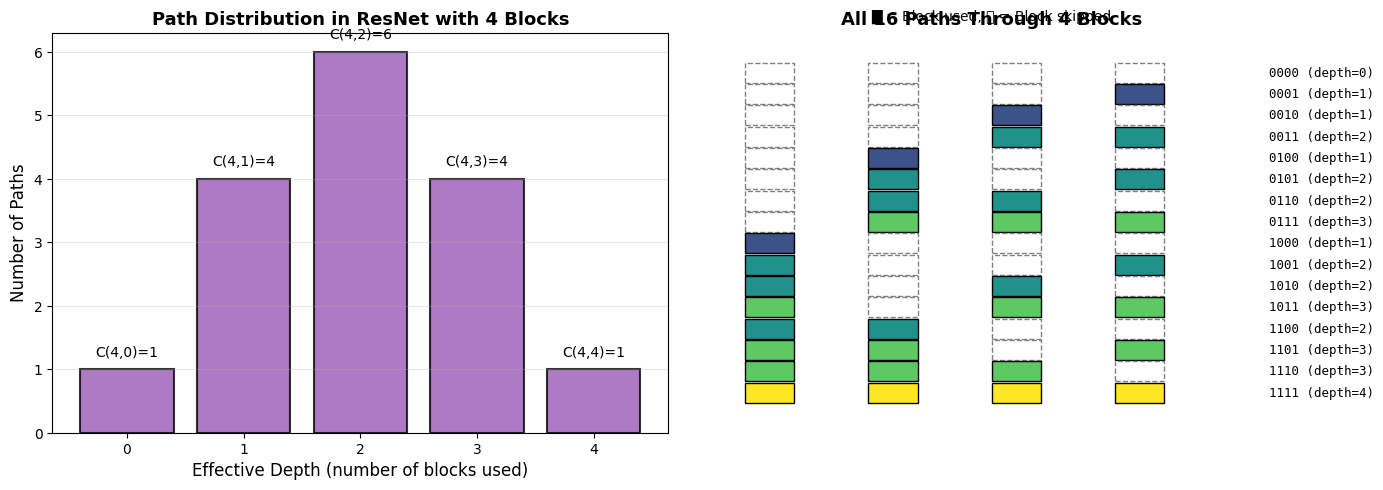


🔢 Path Statistics for 4 blocks:
   Total paths: 16
   Most paths are shallow! (binomial distribution peaks at middle depths)

   This means ResNet effectively trains an ensemble where:
   - Short paths (easy to train) dominate
   - Long paths (harder to train) are just bonus capacity


In [8]:
# Visualize path distribution
n_blocks = 4
n_paths = 2 ** n_blocks

# Count paths by effective depth
from collections import Counter
path_depths = [bin(i).count('1') for i in range(n_paths)]
depth_counts = Counter(path_depths)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of path depths
depths_sorted = sorted(depth_counts.keys())
counts = [depth_counts[d] for d in depths_sorted]

ax1.bar(depths_sorted, counts, color='#9b59b6', alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Effective Depth (number of blocks used)', fontsize=12)
ax1.set_ylabel('Number of Paths', fontsize=12)
ax1.set_title(f'Path Distribution in ResNet with {n_blocks} Blocks', fontsize=13, fontweight='bold')
ax1.set_xticks(depths_sorted)
ax1.grid(True, alpha=0.3, axis='y')

# Add binomial coefficient labels
for d, c in zip(depths_sorted, counts):
    ax1.text(d, c + 0.2, f'C({n_blocks},{d})={c}', ha='center', fontsize=10)

# Show example paths
ax2.axis('off')
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.set_title(f'All {n_paths} Paths Through {n_blocks} Blocks', fontsize=13, fontweight='bold')

# Draw paths
y_positions = np.linspace(9, 1, n_paths)
for path_idx in range(n_paths):
    path_binary = format(path_idx, f'0{n_blocks}b')
    effective_depth = path_binary.count('1')
    
    y = y_positions[path_idx]
    color = plt.cm.viridis(effective_depth / n_blocks)
    
    # Draw path representation
    for i, bit in enumerate(path_binary):
        x = 1 + i * 2
        if bit == '1':
            # Block used - draw filled box
            rect = plt.Rectangle((x, y - 0.25), 0.8, 0.5, facecolor=color, edgecolor='black', linewidth=1)
            ax2.add_patch(rect)
        else:
            # Block skipped - draw dashed box
            rect = plt.Rectangle((x, y - 0.25), 0.8, 0.5, facecolor='white', edgecolor='gray', 
                                 linewidth=1, linestyle='--')
            ax2.add_patch(rect)
    
    # Label
    ax2.text(9.5, y, f'{path_binary} (depth={effective_depth})', fontsize=9, va='center', fontfamily='monospace')

ax2.text(5, 10.3, '█ = Block used, ⬜ = Block skipped', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n🔢 Path Statistics for {n_blocks} blocks:")
print(f"   Total paths: {n_paths}")
print(f"   Most paths are shallow! (binomial distribution peaks at middle depths)")
print(f"\n   This means ResNet effectively trains an ensemble where:")
print(f"   - Short paths (easy to train) dominate")
print(f"   - Long paths (harder to train) are just bonus capacity")


### Verifying Ensemble Behavior: Block Dropping

A key prediction of the ensemble interpretation: **removing individual blocks should have limited impact** because other paths compensate. Let's test this!


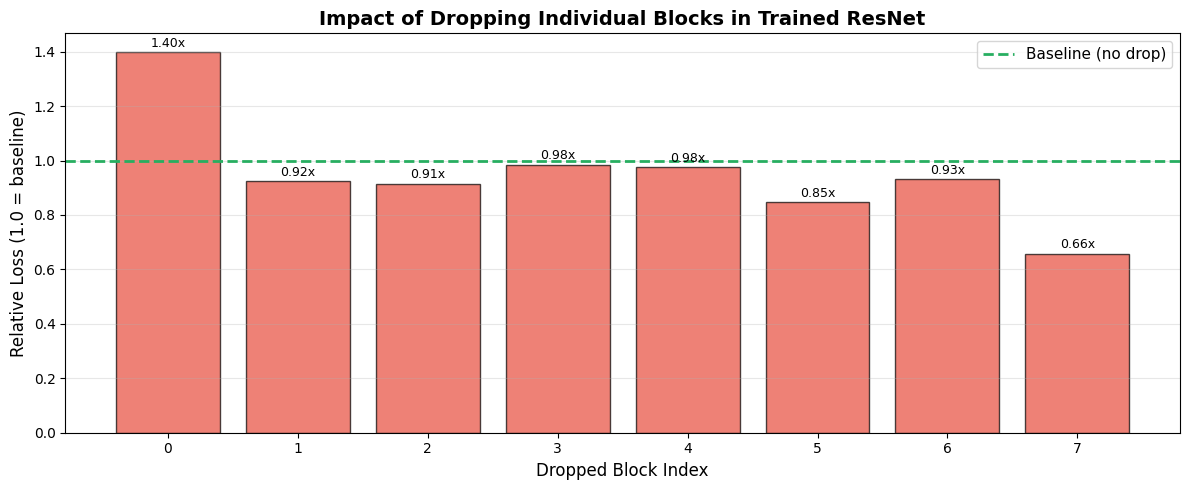


🎯 Ensemble Behavior Confirmed!
   Baseline loss: 0.9416
   Average impact of dropping a block: 0.95x
   Max impact: 1.40x

   → Dropping individual blocks has limited impact because other paths compensate!
   → This is characteristic of ensemble behavior.


In [9]:
class ResNetWithDropout(nn.Module):
    """ResNet where we can drop entire blocks."""
    def __init__(self, n_blocks, size=32):
        super().__init__()
        self.input_proj = nn.Linear(16, size)
        self.blocks = nn.ModuleList([ResidualBlock(size) for _ in range(n_blocks)])
        self.output_proj = nn.Linear(size, 1)
        self.n_blocks = n_blocks
    
    def forward(self, x, drop_mask=None):
        x = F.relu(self.input_proj(x))
        for i, block in enumerate(self.blocks):
            if drop_mask is None or not drop_mask[i]:
                x = block(x)
        return self.output_proj(x)

# Train a ResNet
n_blocks = 8
resnet = ResNetWithDropout(n_blocks).to(device)

# Generate training data
x_train = torch.randn(500, 16, device=device)
y_train = torch.sin(x_train.sum(dim=1, keepdim=True))

optimizer = torch.optim.Adam(resnet.parameters(), lr=0.01)
for _ in range(500):
    optimizer.zero_grad()
    loss = F.mse_loss(resnet(x_train), y_train)
    loss.backward()
    optimizer.step()

# Test with various blocks dropped
x_test = torch.randn(200, 16, device=device)
y_test = torch.sin(x_test.sum(dim=1, keepdim=True))

with torch.no_grad():
    baseline_loss = F.mse_loss(resnet(x_test), y_test).item()

# Drop each block individually
drop_impacts = []
for i in range(n_blocks):
    drop_mask = [False] * n_blocks
    drop_mask[i] = True
    with torch.no_grad():
        dropped_loss = F.mse_loss(resnet(x_test, drop_mask), y_test).item()
    drop_impacts.append(dropped_loss / baseline_loss)

# Visualize
fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(range(n_blocks), drop_impacts, color='#e74c3c', alpha=0.7, edgecolor='black')
ax.axhline(y=1, color='#27ae60', linestyle='--', linewidth=2, label='Baseline (no drop)')
ax.set_xlabel('Dropped Block Index', fontsize=12)
ax.set_ylabel('Relative Loss (1.0 = baseline)', fontsize=12)
ax.set_title('Impact of Dropping Individual Blocks in Trained ResNet', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, v in enumerate(drop_impacts):
    ax.text(i, v + 0.02, f'{v:.2f}x', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n🎯 Ensemble Behavior Confirmed!")
print(f"   Baseline loss: {baseline_loss:.4f}")
print(f"   Average impact of dropping a block: {np.mean(drop_impacts):.2f}x")
print(f"   Max impact: {max(drop_impacts):.2f}x")
print(f"\n   → Dropping individual blocks has limited impact because other paths compensate!")
print(f"   → This is characteristic of ensemble behavior.")


---
## Part 5: Feature Reuse and Information Flow

### Why Skipping Enables Richer Representations

Skip connections don't just help gradients - they enable **feature reuse**:
- Early layer features propagate to later layers unchanged
- Later layers can use both refined AND original features
- The network doesn't have to re-learn basic features at every layer


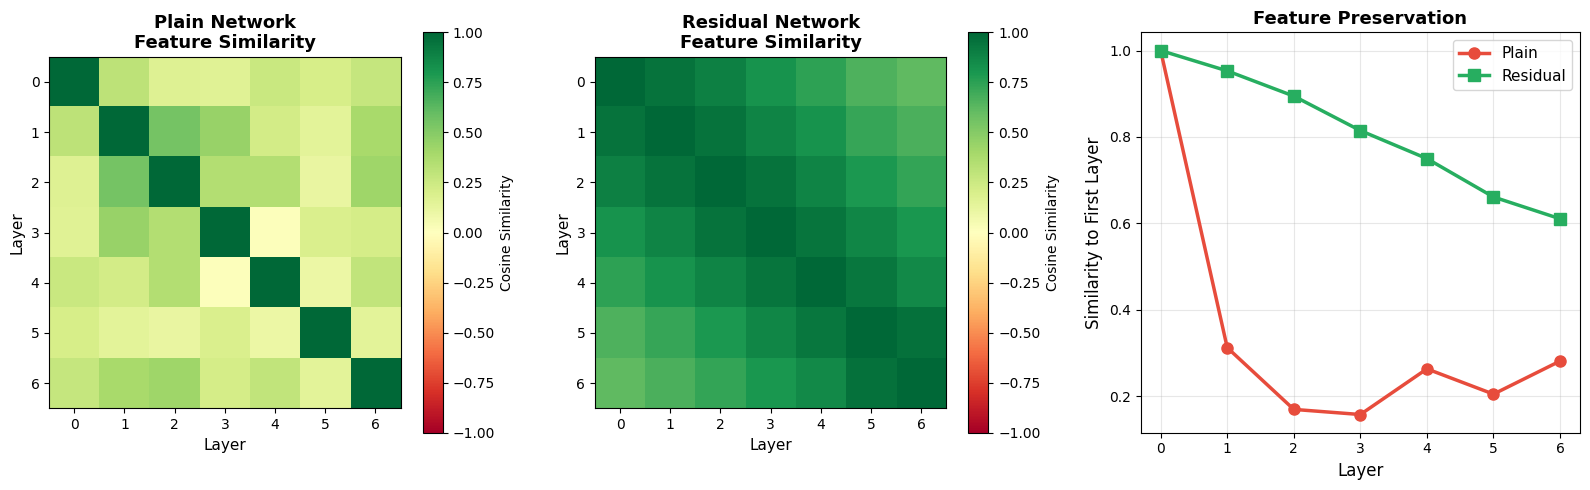


🔄 Feature Reuse Analysis:
   Plain Network:
     - Input-Output similarity: 0.281
     - Features change dramatically through layers

   Residual Network:
     - Input-Output similarity: 0.611
     - Skip connections preserve input information throughout!


In [10]:
class FeatureAnalysisNet(nn.Module):
    """Network that exposes intermediate features for analysis."""
    def __init__(self, n_blocks, size=32, residual=True):
        super().__init__()
        self.input_proj = nn.Linear(16, size)
        self.blocks = nn.ModuleList()
        self.residual = residual
        
        for _ in range(n_blocks):
            self.blocks.append(nn.Sequential(
                nn.Linear(size, size),
                nn.ReLU(),
                nn.Linear(size, size)
            ))
        
        self.output_proj = nn.Linear(size, 1)
    
    def forward_with_features(self, x):
        features = []
        x = F.relu(self.input_proj(x))
        features.append(x.clone())
        
        for block in self.blocks:
            if self.residual:
                x = F.relu(block(x) + x)
            else:
                x = F.relu(block(x))
            features.append(x.clone())
        
        output = self.output_proj(x)
        return output, features

def compute_feature_similarity_matrix(features):
    """Compute cosine similarity between features at different layers."""
    n_layers = len(features)
    similarity = np.zeros((n_layers, n_layers))
    
    for i in range(n_layers):
        for j in range(n_layers):
            # Flatten and compute cosine similarity
            f1 = features[i].flatten()
            f2 = features[j].flatten()
            cos_sim = F.cosine_similarity(f1.unsqueeze(0), f2.unsqueeze(0)).item()
            similarity[i, j] = cos_sim
    
    return similarity

# Create and train both types of networks
n_blocks = 6
plain_net = FeatureAnalysisNet(n_blocks, residual=False).to(device)
res_net = FeatureAnalysisNet(n_blocks, residual=True).to(device)

# Training data
x_data = torch.randn(200, 16, device=device)
y_data = torch.sin(x_data.sum(dim=1, keepdim=True))

# Train both
for model in [plain_net, res_net]:
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    for _ in range(300):
        optimizer.zero_grad()
        output, _ = model.forward_with_features(x_data)
        loss = F.mse_loss(output, y_data)
        loss.backward()
        optimizer.step()

# Analyze features
with torch.no_grad():
    x_test = torch.randn(100, 16, device=device)
    _, plain_features = plain_net.forward_with_features(x_test)
    _, res_features = res_net.forward_with_features(x_test)

plain_sim = compute_feature_similarity_matrix(plain_features)
res_sim = compute_feature_similarity_matrix(res_features)

# Visualize
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

im1 = ax1.imshow(plain_sim, cmap='RdYlGn', vmin=-1, vmax=1)
ax1.set_xlabel('Layer', fontsize=11)
ax1.set_ylabel('Layer', fontsize=11)
ax1.set_title('Plain Network\nFeature Similarity', fontsize=13, fontweight='bold')
plt.colorbar(im1, ax=ax1, label='Cosine Similarity')

im2 = ax2.imshow(res_sim, cmap='RdYlGn', vmin=-1, vmax=1)
ax2.set_xlabel('Layer', fontsize=11)
ax2.set_ylabel('Layer', fontsize=11)
ax2.set_title('Residual Network\nFeature Similarity', fontsize=13, fontweight='bold')
plt.colorbar(im2, ax=ax2, label='Cosine Similarity')

# Feature reuse: similarity with first layer
layers = range(len(plain_features))
ax3.plot(layers, plain_sim[0, :], 'o-', linewidth=2.5, markersize=8, 
         label='Plain', color='#e74c3c')
ax3.plot(layers, res_sim[0, :], 's-', linewidth=2.5, markersize=8, 
         label='Residual', color='#27ae60')
ax3.set_xlabel('Layer', fontsize=12)
ax3.set_ylabel('Similarity to First Layer', fontsize=12)
ax3.set_title('Feature Preservation', fontsize=13, fontweight='bold')
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n🔄 Feature Reuse Analysis:")
print(f"   Plain Network:")
print(f"     - Input-Output similarity: {plain_sim[0, -1]:.3f}")
print(f"     - Features change dramatically through layers")
print(f"\n   Residual Network:")
print(f"     - Input-Output similarity: {res_sim[0, -1]:.3f}")
print(f"     - Skip connections preserve input information throughout!")


### The Information Bottleneck Perspective

Without skip connections:
- Each layer must encode ALL useful information about the input
- Information can be lost through compression at each layer
- Later layers may lose access to important early features

With skip connections:
- Raw input information propagates directly to later layers
- Each block only needs to learn refinements
- No information bottleneck - all information is available everywhere


---
## Summary: Why Residual Connections Work

### The Five Key Reasons

1. **Easy Identity Learning**: Learning $F(x) = 0$ is easier than learning $H(x) = x$

2. **Gradient Highway**: The $+1$ term in $\frac{\partial}{\partial x}(F(x) + x)$ prevents vanishing gradients

3. **Implicit Ensemble**: $2^n$ paths through $n$ blocks provide robustness and regularization

4. **Feature Reuse**: Input information propagates unchanged to all layers

5. **Modular Learning**: Each block learns small refinements, not complete transformations


In [11]:
# Final comprehensive comparison
def train_and_evaluate(model, x_train, y_train, x_test, y_test, epochs=300):
    """Train model and return loss history."""
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    train_losses = []
    test_losses = []
    
    for epoch in range(epochs):
        # Train
        model.train()
        optimizer.zero_grad()
        output = model(x_train)
        loss = F.mse_loss(output, y_train)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        
        # Evaluate
        model.eval()
        with torch.no_grad():
            test_loss = F.mse_loss(model(x_test), y_test).item()
        test_losses.append(test_loss)
    
    return train_losses, test_losses

class DeepPlainNet(nn.Module):
    def __init__(self, depth, size=64):
        super().__init__()
        layers = [nn.Linear(16, size), nn.ReLU()]
        for _ in range(depth - 2):
            layers.extend([nn.Linear(size, size), nn.ReLU()])
        layers.append(nn.Linear(size, 1))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)

class DeepResNet(nn.Module):
    def __init__(self, depth, size=64):
        super().__init__()
        self.input_proj = nn.Linear(16, size)
        self.blocks = nn.ModuleList([ResidualBlock(size) for _ in range(depth // 2)])
        self.output_proj = nn.Linear(size, 1)
    
    def forward(self, x):
        x = F.relu(self.input_proj(x))
        for block in self.blocks:
            x = block(x)
        return self.output_proj(x)

# Generate data
torch.manual_seed(42)
x_train = torch.randn(500, 16, device=device)
y_train = torch.sin(x_train.sum(dim=1, keepdim=True)) + 0.5 * torch.cos(x_train[:, :4].sum(dim=1, keepdim=True))
x_test = torch.randn(200, 16, device=device)
y_test = torch.sin(x_test.sum(dim=1, keepdim=True)) + 0.5 * torch.cos(x_test[:, :4].sum(dim=1, keepdim=True))

# Compare at different depths
depths = [10, 20, 40]
results = {}

print("Training networks at various depths...\n")
for depth in depths:
    print(f"Depth {depth}:")
    
    # Plain network
    plain = DeepPlainNet(depth).to(device)
    plain_train, plain_test = train_and_evaluate(plain, x_train, y_train, x_test, y_test)
    print(f"  Plain:    Final test loss = {plain_test[-1]:.4f}")
    
    # ResNet
    resnet = DeepResNet(depth).to(device)
    res_train, res_test = train_and_evaluate(resnet, x_train, y_train, x_test, y_test)
    print(f"  Residual: Final test loss = {res_test[-1]:.4f}")
    print()
    
    results[depth] = {
        'plain_train': plain_train, 'plain_test': plain_test,
        'res_train': res_train, 'res_test': res_test
    }


Training networks at various depths...

Depth 10:
  Plain:    Final test loss = 1.1287
  Residual: Final test loss = 1.1886

Depth 20:
  Plain:    Final test loss = 1.1563
  Residual: Final test loss = 1.0578

Depth 40:
  Plain:    Final test loss = 0.6742
  Residual: Final test loss = 0.8848



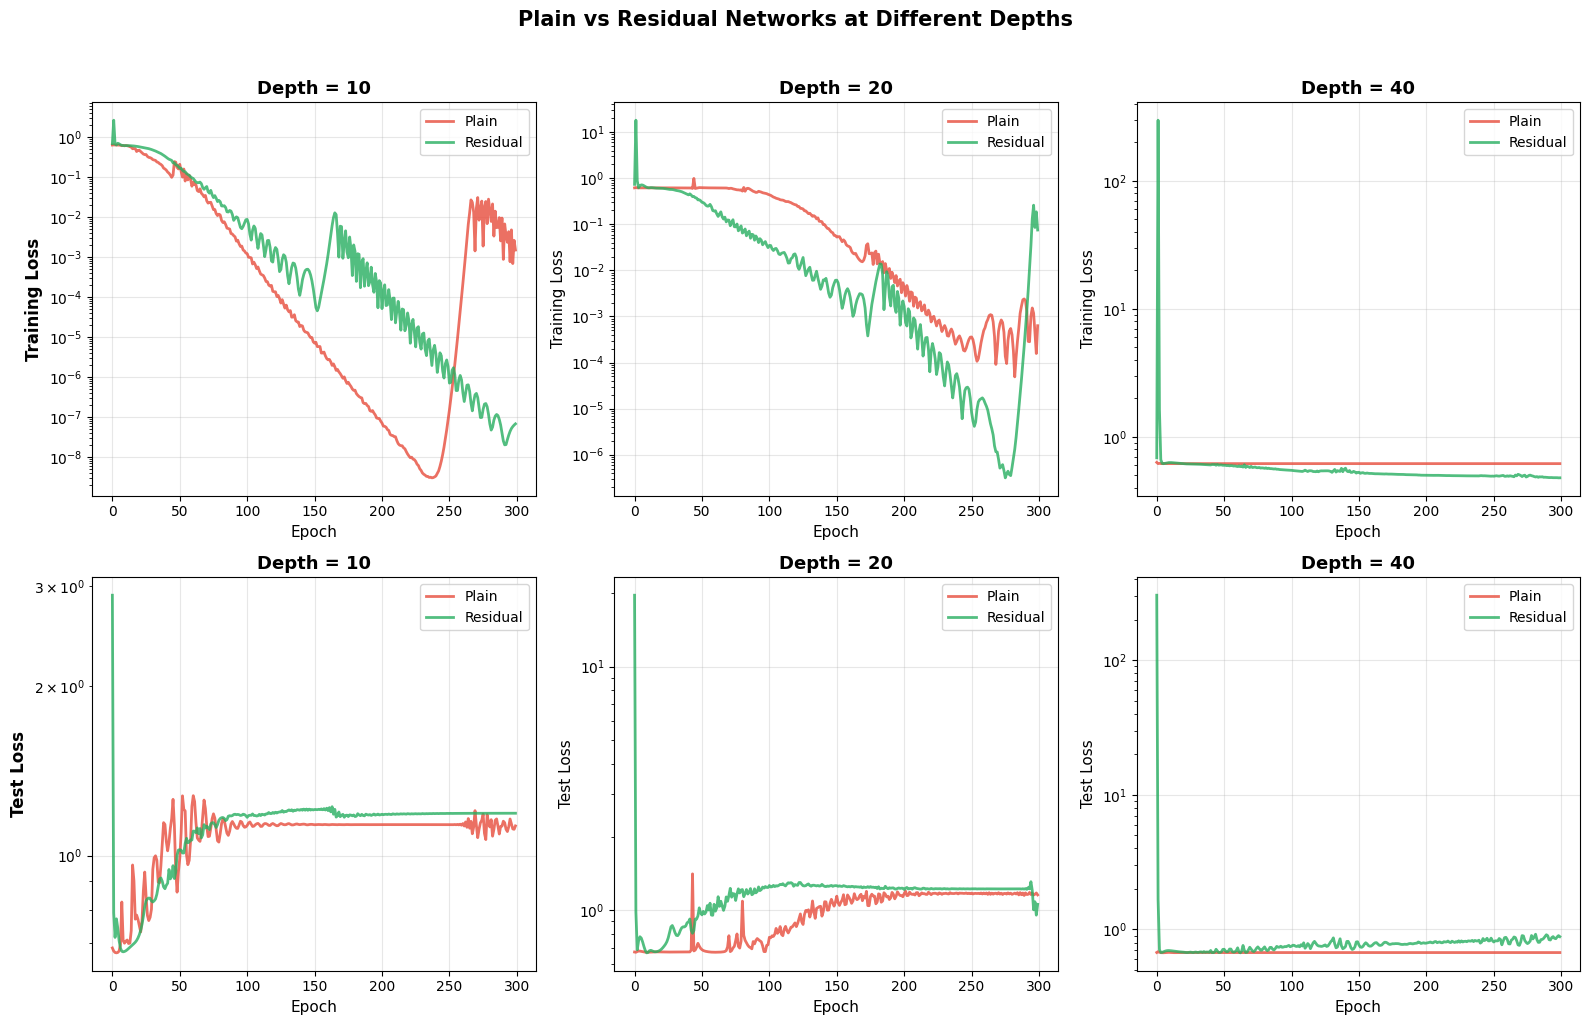

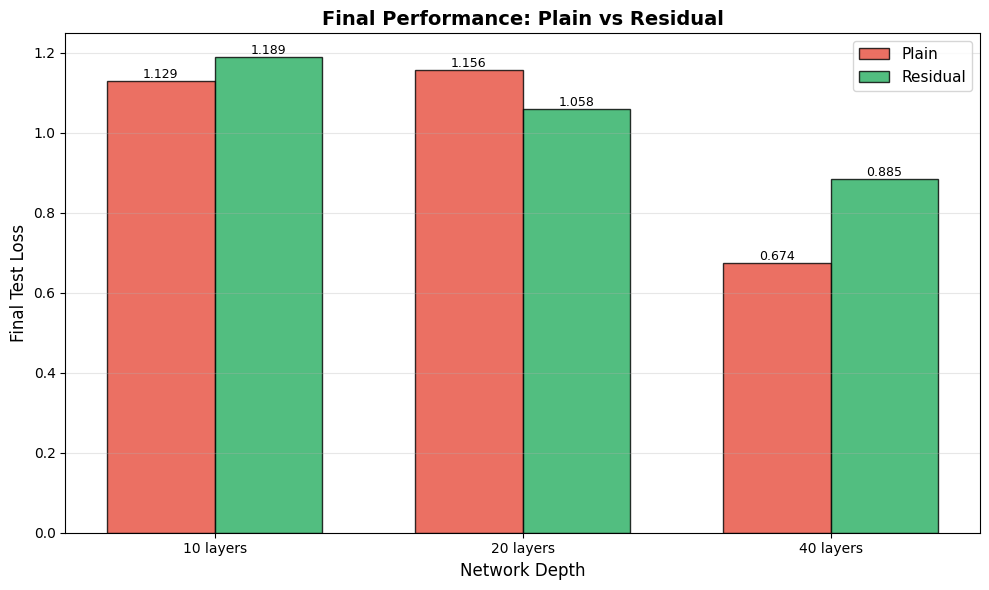


KEY TAKEAWAY

Residual connections enable deep networks to train effectively
where plain networks fail. The simple addition of `+ x` creates:

  1. Gradient highways that prevent vanishing gradients
  2. Implicit ensembles for robustness
  3. Feature reuse for richer representations
  4. Easier optimization (learning residuals vs full functions)

This one simple idea revolutionized deep learning!


In [12]:
# Visualization of final comparison
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for idx, depth in enumerate(depths):
    r = results[depth]
    
    # Training curves (top row)
    axes[0, idx].plot(r['plain_train'], label='Plain', color='#e74c3c', linewidth=2, alpha=0.8)
    axes[0, idx].plot(r['res_train'], label='Residual', color='#27ae60', linewidth=2, alpha=0.8)
    axes[0, idx].set_xlabel('Epoch', fontsize=11)
    axes[0, idx].set_ylabel('Training Loss', fontsize=11)
    axes[0, idx].set_title(f'Depth = {depth}', fontsize=13, fontweight='bold')
    axes[0, idx].legend(fontsize=10)
    axes[0, idx].set_yscale('log')
    axes[0, idx].grid(True, alpha=0.3)
    
    # Test curves (bottom row)
    axes[1, idx].plot(r['plain_test'], label='Plain', color='#e74c3c', linewidth=2, alpha=0.8)
    axes[1, idx].plot(r['res_test'], label='Residual', color='#27ae60', linewidth=2, alpha=0.8)
    axes[1, idx].set_xlabel('Epoch', fontsize=11)
    axes[1, idx].set_ylabel('Test Loss', fontsize=11)
    axes[1, idx].set_title(f'Depth = {depth}', fontsize=13, fontweight='bold')
    axes[1, idx].legend(fontsize=10)
    axes[1, idx].set_yscale('log')
    axes[1, idx].grid(True, alpha=0.3)

axes[0, 0].set_ylabel('Training Loss', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Test Loss', fontsize=12, fontweight='bold')

plt.suptitle('Plain vs Residual Networks at Different Depths', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary bar chart
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(depths))
width = 0.35

plain_finals = [results[d]['plain_test'][-1] for d in depths]
res_finals = [results[d]['res_test'][-1] for d in depths]

bars1 = ax.bar(x - width/2, plain_finals, width, label='Plain', color='#e74c3c', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, res_finals, width, label='Residual', color='#27ae60', alpha=0.8, edgecolor='black')

ax.set_xlabel('Network Depth', fontsize=12)
ax.set_ylabel('Final Test Loss', fontsize=12)
ax.set_title('Final Performance: Plain vs Residual', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'{d} layers' for d in depths])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.3f}',
            ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.3f}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("KEY TAKEAWAY")
print("="*60)
print("\nResidual connections enable deep networks to train effectively")
print("where plain networks fail. The simple addition of `+ x` creates:")
print("\n  1. Gradient highways that prevent vanishing gradients")
print("  2. Implicit ensembles for robustness")
print("  3. Feature reuse for richer representations")
print("  4. Easier optimization (learning residuals vs full functions)")
print("\nThis one simple idea revolutionized deep learning!")
print("="*60)


---
## Further Reading

### Papers
- [Deep Residual Learning for Image Recognition](https://arxiv.org/abs/1512.03385) (He et al., 2015) - The original ResNet paper
- [Identity Mappings in Deep Residual Networks](https://arxiv.org/abs/1603.05027) (He et al., 2016) - Pre-activation design
- [Residual Networks Behave Like Ensembles of Relatively Shallow Networks](https://arxiv.org/abs/1605.06431) (Veit et al., 2016) - Ensemble interpretation
- [Visualizing the Loss Landscape of Neural Nets](https://arxiv.org/abs/1712.09913) (Li et al., 2018) - Loss landscape analysis

### Connections to Other Architectures
- **Transformers**: Use residual connections around attention and FFN layers
- **DenseNet**: Extends skip connections to connect ALL previous layers
- **U-Net**: Skip connections between encoder and decoder for segmentation
- **Highway Networks**: Learnable gates to control skip vs transform paths
